In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [2]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_synthetic_dataset.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,occupancy,operating_hours,outdoor_temp,humidity,insulation,ventilation,glass_ratio,heat_gain,cooling_load,tonnage,energy_consumption,installation_cost,efficiency_score,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,21.00000,13.0,36.03,81.14,Good,Standard,Low,901.27,913.11,0.08,37.520000,3828.88,100.0,Split AC
1,Residential,Humid,Low,1955.46,1.0,39.00000,6.0,32.90,85.98,Poor,Poor,Medium,4095.95,3927.06,0.33,67.000000,16018.71,74.0,Split AC
2,Office,Hot,Medium,34870.54,1.0,2877.00000,9.0,32.12,36.31,Good,Standard,Medium,146008.53,146787.13,12.23,4534.820000,1010119.61,55.0,Multi-Split
3,Office,Humid,High,28161.83,3.0,6557.44668,11.0,33.26,75.96,Excellent,Standard,High,89833.08,169295.39,7.57,6167.724905,642643.12,38.0,Multi-Split
4,Residential,Warm,Low,2031.88,1.0,37.00000,12.0,29.44,59.70,Poor,Poor,Low,3185.87,3500.26,0.29,107.810000,14382.38,74.0,Split AC


In [ ]:
data.info()

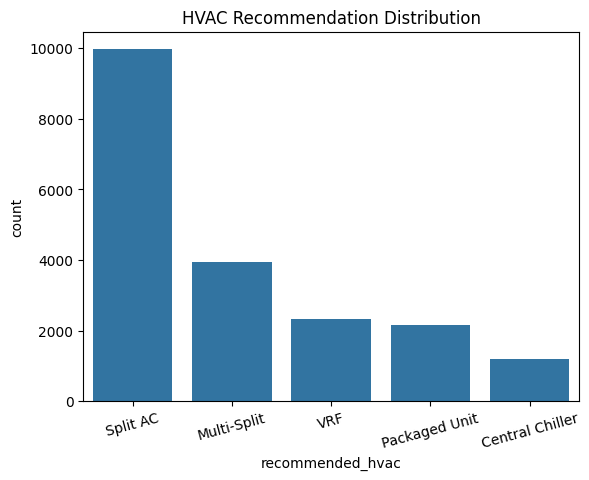

In [4]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [5]:
print(
    data["recommended_hvac"]
    .value_counts(normalize=True) * 100
)

recommended_hvac
Split AC           50.875491
Multi-Split        20.149063
VRF                11.930165
Packaged Unit      10.975548
Central Chiller     6.069733
Name: proportion, dtype: float64


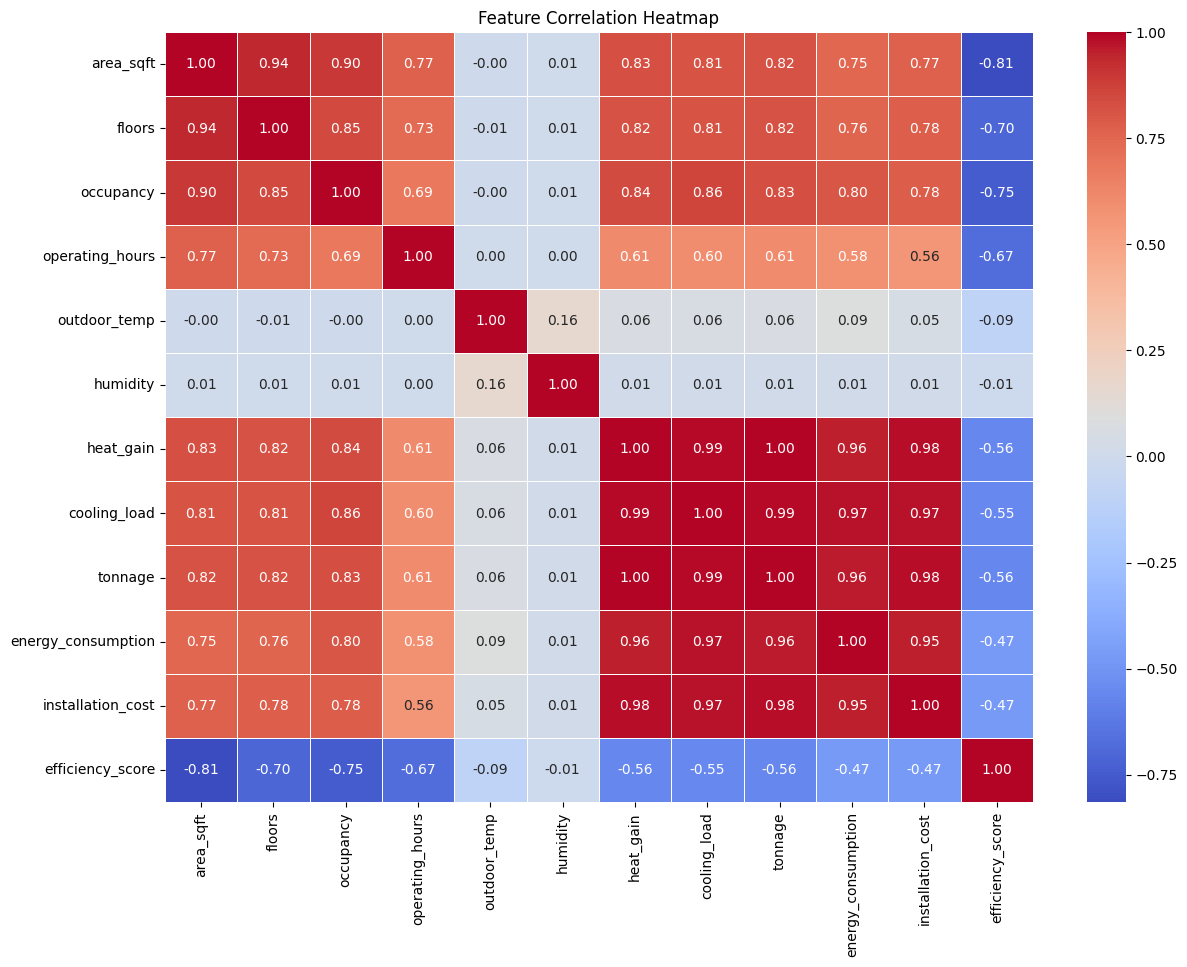

In [6]:
numeric_df = data.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs != 1]

display(corr_pairs.head(20))

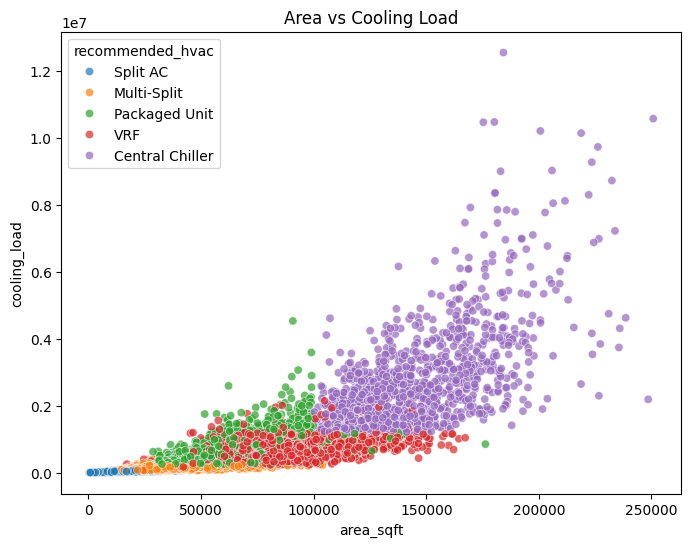

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="area_sqft",
    y="cooling_load",
    hue="recommended_hvac",
    alpha=0.7
)

plt.title("Area vs Cooling Load")
plt.show()